# Entrega 2: corpus Duque, textometria y topicos

El export contiene 708,768 registros de 6 medios entre 2018-08-07 y 2022-08-06. Hay 707,553 titulos slug y 1,215 ausentes. Se entrenaron K=[3, 5, 7, 10, 15] sobre 706,083 documentos utiles, con 10 pasadas y semilla 42. K=5 obtuvo el mayor c_v (0.3595) de la grilla.

## 1. Alcance y limitaciones

- Todos los titulos disponibles son proxies slug; no titulares editoriales verificados.
- No hay cuerpos HTML: no se pueden estudiar citas, actores en contexto o framing textual completo.
- Cinco medios principales y Cambio con 98 articulos: no ocho medios comparables.
- Las fechas month y lastmod requieren cautela; un corte por fecha no certifica gobierno.
- Keywords seleccionan temas/candidatos, no eventos verificados ni omisiones demostradas.
- LDA/coherencia se evaluan en entrenamiento; el mejor K no es un optimo universal.
- Programas, emisiones y audio forman parte del archivo; la mezcla de formatos puede dominar las frecuencias.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display
candidates = [Path('resultados'), Path('entrega2/resultados'), Path('workshops/media-bias-detection/entrega2/resultados'), Path('natural-language-processing-workshops/workshops/media-bias-detection/entrega2/resultados')]
RESULTS = next((path for path in candidates if (path / 'resumen.json').exists()), None)
assert RESULTS is not None, 'No se encuentra la carpeta de resultados de Entrega 2'
summary = json.loads((RESULTS / 'resumen.json').read_text())
display(pd.read_csv(RESULTS / 'resumen_analisis.csv'))

,Metrica,Valor
0,Articulos del export,708768.000000
1,Medios presentes,6.000000
2,Titulos disponibles (slug),707553.000000
3,Titulos ausentes,1215.000000
4,Vocabulario depurado,98418.000000
5,Documentos utiles LDA,706083.000000
6,K con mayor coherencia c_v,5.000000
7,Coherencia c_v,0.359546


In [2]:
display(pd.read_csv(RESULTS / 'cobertura_corpus.csv'))
display(pd.read_csv(RESULTS / 'precision_gobierno.csv'))

,source_id,articulos,con_titulo,desde,hasta,tokens_promedio,sin_titulo,pct_titulo
0,blu_radio,166593,165916,2018-08-07,2022-08-06,7.126764,677,99.593620
1,cambio,98,98,2022-08-01,2022-08-06,4.857143,0,100.000000
2,el_tiempo,263145,262968,2018-08-07,2022-08-06,6.040210,177,99.932737
3,la_republica,91801,91743,2018-08-07,2022-08-06,6.789490,58,99.936820
4,noticias_caracol,109384,109085,2018-08-07,2022-08-06,7.435704,299,99.726651
5,noticias_rcn,77747,77743,2018-09-01,2022-08-06,6.733379,4,99.994855


,source_id,date_precision,government_id,articulos
0,blu_radio,day,duque,159849
1,blu_radio,month,duque,6651
2,blu_radio,month,NaN,93
3,cambio,day,duque,98
4,el_tiempo,day,duque,263145
5,la_republica,day,duque,89131
6,la_republica,month,duque,2635
7,la_republica,month,NaN,35
8,noticias_caracol,day,duque,104235
9,noticias_caracol,month,duque,5110


La representacion de medios es desigual; Cambio es una submuestra tardia.

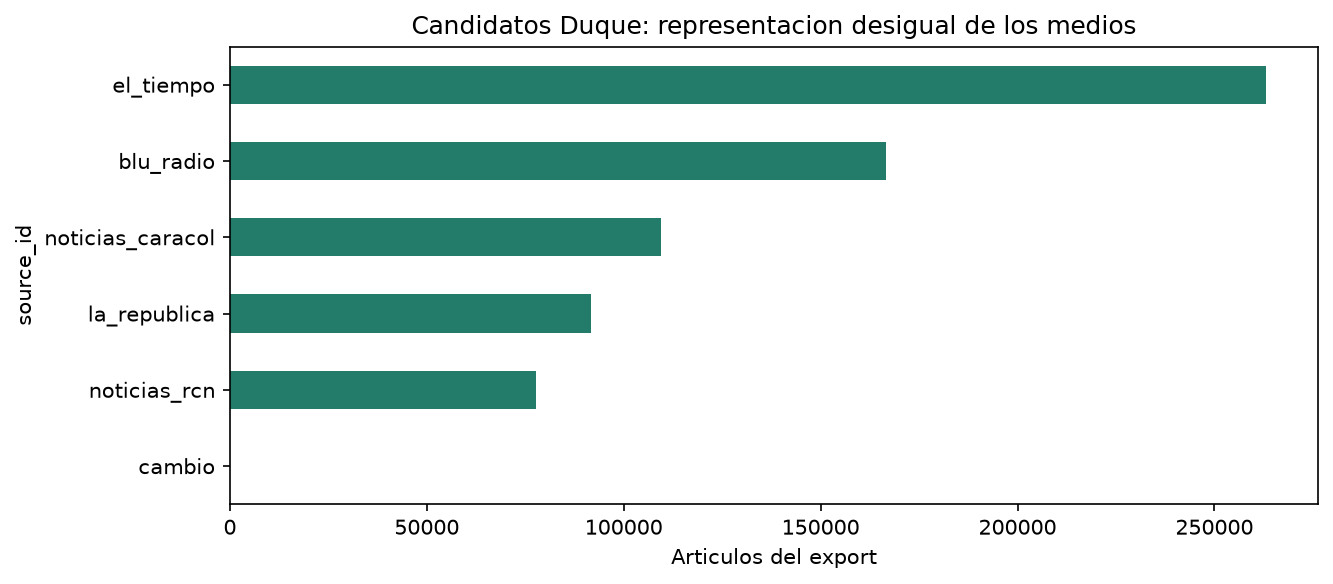

In [3]:
display(Image(filename=str(RESULTS / 'figuras' / 'cobertura_corpus.png')))

## 2. Textometria

Minusculas y tildes normalizadas; stopwords NLTK y verbos de reporte. Se conservan geografia y actores. Una pendiente/correlacion log-log es descriptiva, no una prueba de ley de potencia. TTR depende de longitud; MSTTR agregado usa ventanas completas de 50 tokens. Yule K = 10000 * sum(f*(f-1))/N^2. Los n-gramas son adyacencias despues de filtrar stopwords.

In [4]:
display(pd.read_csv(RESULTS / 'frecuencias.csv').head(20))
display(pd.read_csv(RESULTS / 'diversidad_por_medio.csv'))

,palabra,frecuencia,rango
0,colombia,44294,1
1,bogota,33868,2
2,covid,26911,3
3,video,21600,4
4,coronavirus,20704,5
5,tras,18896,6
6,anos,17480,7
7,medellin,14487,8
8,asi,14207,9
9,cali,14186,10


,source_id,tokens,vocabulario,ttr_agregado,yule_k_agregado,msttr_50_agregado,ttr_titulo_media,yule_k_titulo_media,tokens_titulo_media,documentos_utiles
0,blu_radio,1187269,51645,0.043499,7.568221,0.959712,0.997534,7.009615,7.155930,165914
1,cambio,476,382,0.802521,22.685545,0.957778,0.998542,4.164931,4.857143,98
2,el_tiempo,1589451,64124,0.040343,7.346644,0.953985,0.996250,11.452255,6.044275,262968
3,la_republica,623282,38854,0.062338,7.765411,0.972207,0.997762,7.921380,6.794745,91730
4,noticias_caracol,813347,43469,0.053445,8.798836,0.958202,0.998735,3.261677,7.456153,109084
5,noticias_rcn,523500,33450,0.063897,8.168564,0.956980,0.998818,3.402897,6.733812,77742


Ajuste descriptivo: pendiente -1.035, R2=0.969; no certifica Zipf.

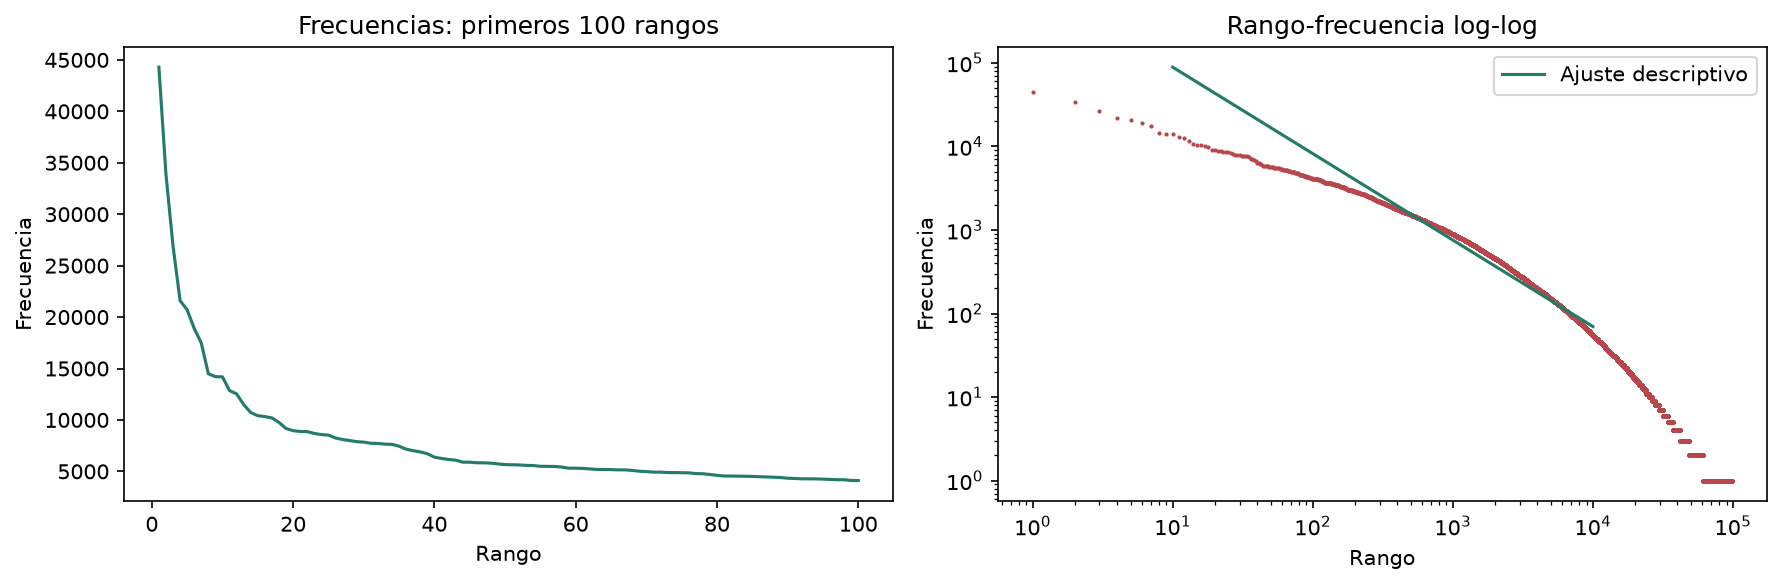

In [5]:
display(Image(filename=str(RESULTS / 'figuras' / 'zipf_law.png')))

Diversidad por medio: no comparar TTR agregado sin controlar longitud/muestra.

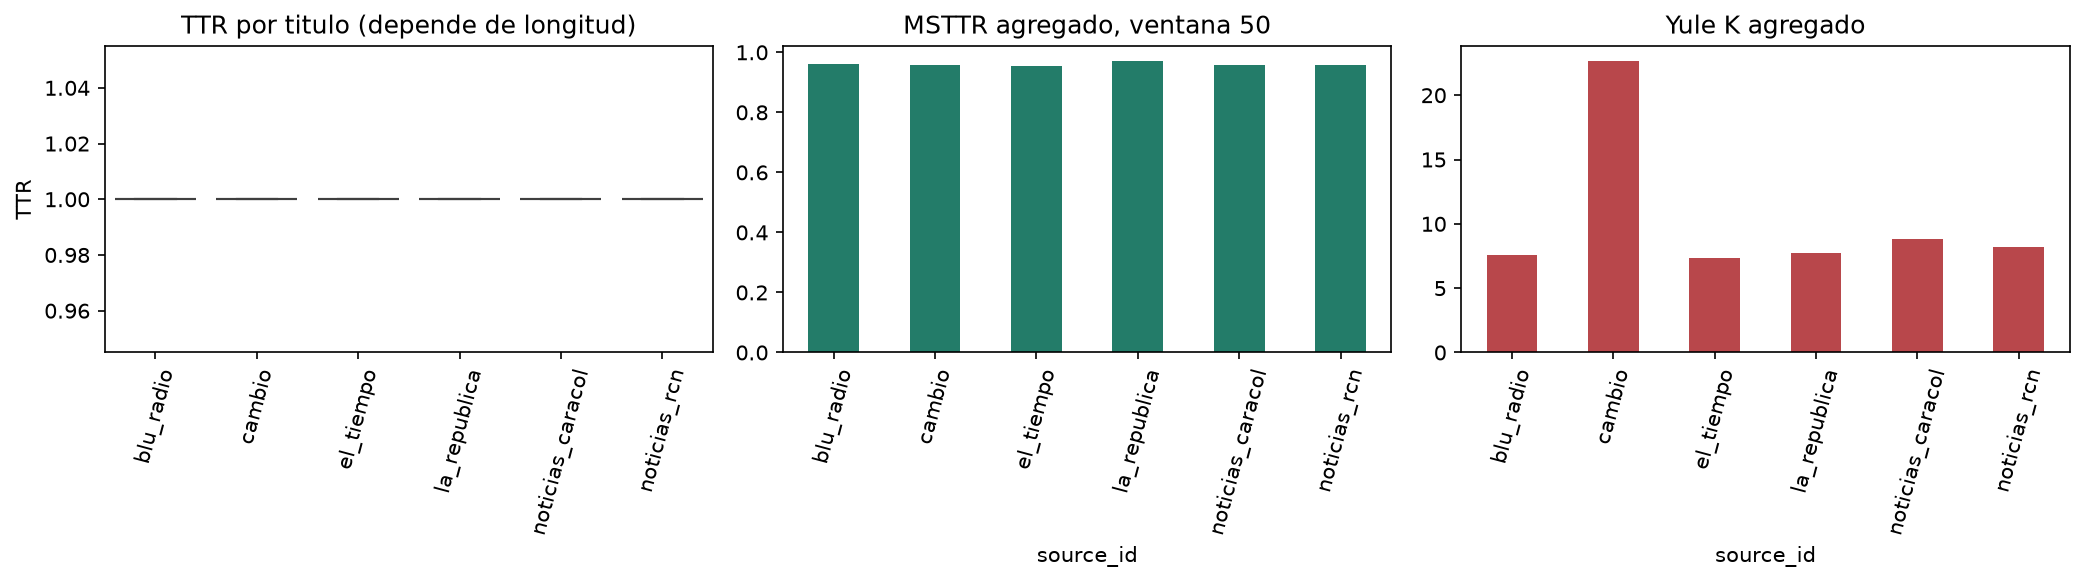

In [6]:
display(Image(filename=str(RESULTS / 'figuras' / 'lexical_diversity.png')))

N-gramas depurados; frecuencia no equivale a significancia estadistica. El bigrama mas frecuente es 'programa completo' (8,822 apariciones). Programacion de radio y emisiones condicionan los resultados; no confundir formato con posicion editorial.

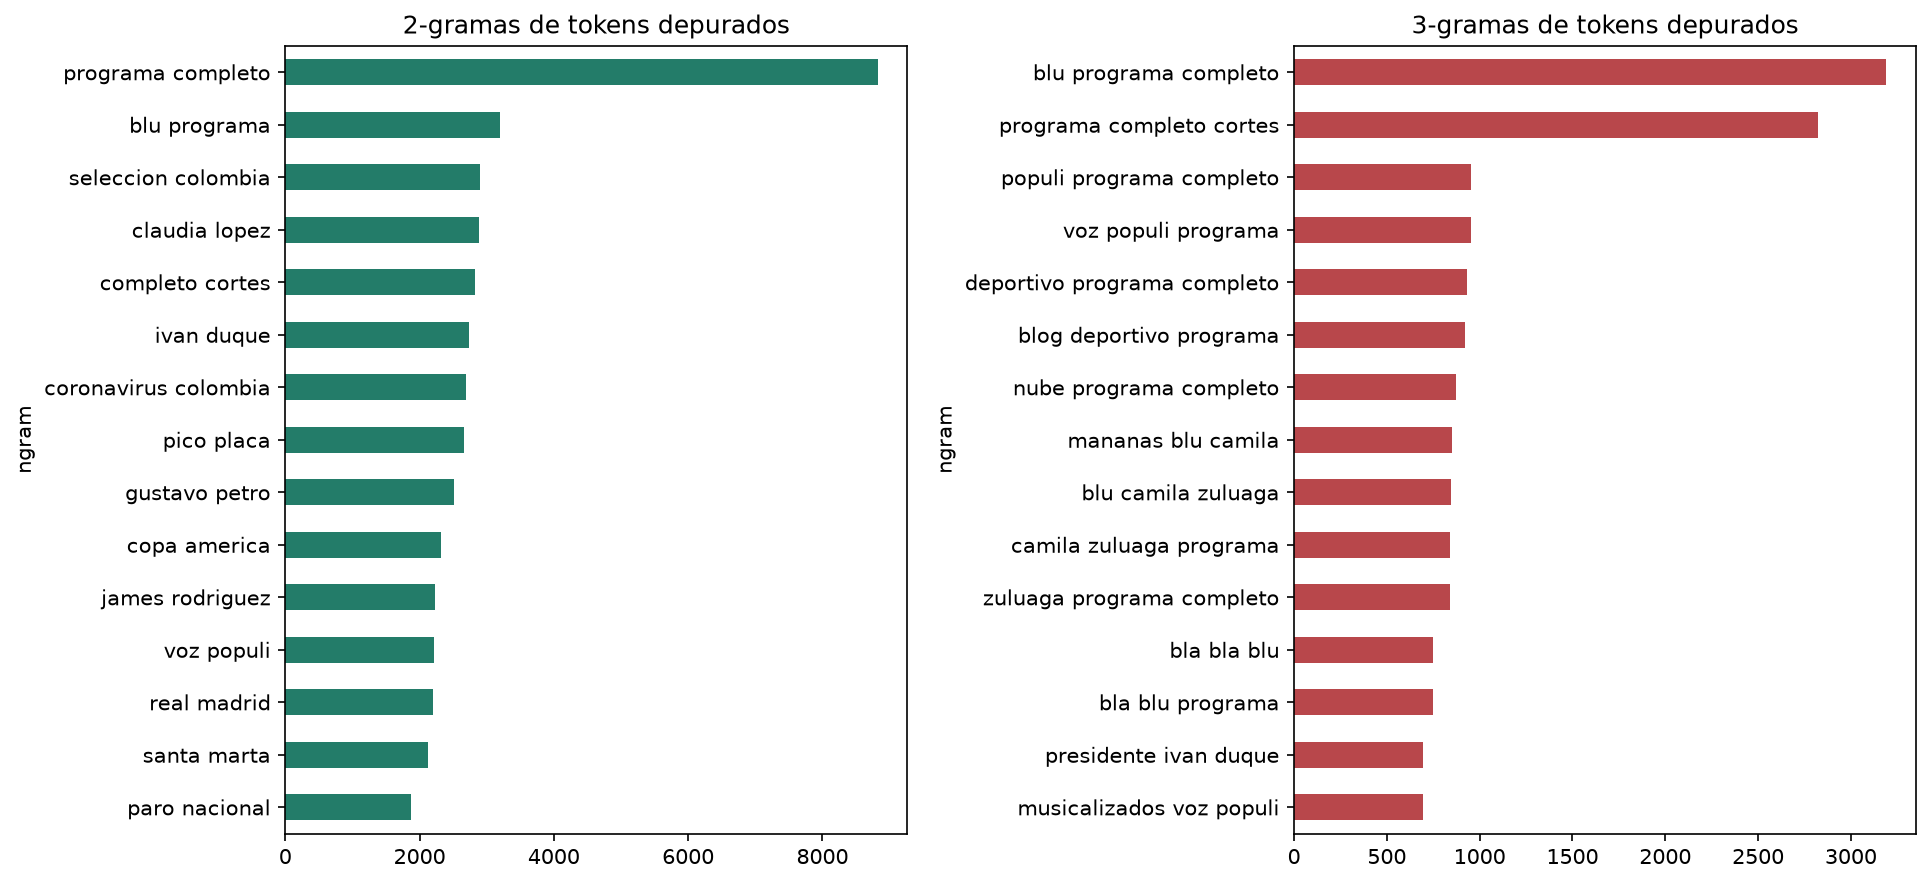

In [7]:
display(Image(filename=str(RESULTS / 'figuras' / 'ngrams.png')))

In [8]:
display(pd.read_csv(RESULTS / 'bigrams_top100.csv').head(30))
display(pd.read_csv(RESULTS / 'trigrams_top50.csv').head(20))

,ngram,frecuencia,documentos
0,programa completo,8822,8822
1,blu programa,3191,3191
2,seleccion colombia,2901,2899
3,claudia lopez,2881,2879
4,completo cortes,2825,2825
5,ivan duque,2738,2737
6,coronavirus colombia,2686,2686
7,pico placa,2664,2649
8,gustavo petro,2516,2516
9,copa america,2318,2313


,ngram,frecuencia,documentos
0,blu programa completo,3191,3191
1,programa completo cortes,2825,2825
2,populi programa completo,954,954
3,voz populi programa,954,954
4,deportivo programa completo,931,931
5,blog deportivo programa,919,919
6,nube programa completo,874,874
7,mananas blu camila,849,849
8,blu camila zuluaga,848,848
9,camila zuluaga programa,839,839


## 3. Temas y casos temporales

Proporciones respecto a los titulos disponibles de cada medio. No hallar keywords no prueba ausencia de cobertura. Los casos temporales son candidatos a revision humana, no clusters certificados del mismo hecho. Los log-odds son descriptivos, sin significancia inferencial.

In [9]:
display(pd.read_csv(RESULTS / 'eventos_polemicos.csv'))
display(pd.read_csv(RESULTS / 'casos_temporales.csv'))
display(pd.read_csv(RESULTS / 'ejemplos_casos.csv').head(18))
display(pd.read_csv(RESULTS / 'contrastes_lexicos.csv').head(30))

,tema,source_id,articulos,denominador_titulos,pct_medio
0,Reforma tributaria,blu_radio,689,165916,0.415270
1,Reforma tributaria,cambio,0,98,0.000000
2,Reforma tributaria,el_tiempo,1067,262968,0.405753
3,Reforma tributaria,la_republica,989,91743,1.078011
4,Reforma tributaria,noticias_caracol,345,109085,0.316267
5,Reforma tributaria,noticias_rcn,284,77743,0.365306
6,Conflicto armado,blu_radio,3268,165916,1.969671
7,Conflicto armado,cambio,0,98,0.000000
8,Conflicto armado,el_tiempo,3494,262968,1.328679
9,Conflicto armado,la_republica,92,91743,0.100280


,caso,source_id,articulos,titulos_ventana,pct_ventana
0,Reforma y paro 2021,blu_radio,354,7550,4.688742
1,Reforma y paro 2021,cambio,0,0,NaN
2,Reforma y paro 2021,el_tiempo,745,13989,5.325613
3,Reforma y paro 2021,la_republica,64,4784,1.337793
4,Reforma y paro 2021,noticias_caracol,209,3936,5.309959
5,Reforma y paro 2021,noticias_rcn,75,3274,2.290776
6,Bombardeo y menores 2019,blu_radio,32,1510,2.119205
7,Bombardeo y menores 2019,cambio,0,0,NaN
8,Bombardeo y menores 2019,el_tiempo,22,1969,1.117318
9,Bombardeo y menores 2019,la_republica,1,1017,0.098328


,caso,article_id,source_id,fecha,date_precision,title_source,title,url
0,Reforma y paro 2021,760911,blu_radio,2021-04-15,day,slug,Reforma tributaria propondria que estratos al ...,https://www.bluradio.com/economia/reforma-trib...
1,Reforma y paro 2021,760940,blu_radio,2021-04-15,day,slug,Reforma tributaria conozca el listado de produ...,https://www.bluradio.com/economia/reforma-trib...
2,Reforma y paro 2021,760962,blu_radio,2021-04-15,day,slug,Reforma tributaria duque pide al congreso apoy...,https://www.bluradio.com/economia/reforma-trib...
3,Reforma y paro 2021,433079,el_tiempo,2021-04-15,day,slug,Reforma tributaria asi sera el freno en el gas...,https://www.eltiempo.com/economia/sectores/ref...
4,Reforma y paro 2021,433080,el_tiempo,2021-04-15,day,slug,Reforma tributaria quien debe pagar el impuest...,https://www.eltiempo.com/economia/sectores/ref...
5,Reforma y paro 2021,433095,el_tiempo,2021-04-15,day,slug,Politicos reaccionan a la radicacion de la ref...,https://www.eltiempo.com/politica/politicos-re...
6,Reforma y paro 2021,896767,la_republica,2021-04-15,day,slug,Esto es lo que trae la reforma tributaria que ...,https://www.larepublica.co/economia/esto-es-lo...
7,Reforma y paro 2021,896810,la_republica,2021-04-15,day,slug,Estos son todos los puntos que incluye la terc...,https://www.larepublica.co/economia/estos-son-...
8,Reforma y paro 2021,896861,la_republica,2021-04-15,day,slug,Los impuestos a los mas ricos que tiene la ref...,https://www.larepublica.co/economia/los-impues...
9,Reforma y paro 2021,682382,noticias_caracol,2021-04-15,day,slug,Subir iva al cafe sal azucar y chocolate crece...,https://www.noticiascaracol.com/politica/subir...


,tema,source_id,palabra,frecuencia,log_odds_descriptivo
0,Reforma tributaria,blu_radio,paola,10,3.190789
1,Reforma tributaria,blu_radio,ochoa,10,2.679908
2,Reforma tributaria,blu_radio,bucaramanga,24,2.305814
3,Reforma tributaria,blu_radio,opinion,10,2.092010
4,Reforma tributaria,blu_radio,antioquia,7,1.754956
5,Reforma tributaria,blu_radio,democratico,10,1.724173
6,Reforma tributaria,blu_radio,minhacienda,32,1.708908
7,Reforma tributaria,blu_radio,marchas,6,1.611661
8,Reforma tributaria,blu_radio,centro,10,1.581016
9,Reforma tributaria,blu_radio,andi,6,1.410935


Cobertura relativa de temas, no prueba de framing o bias. La Republica tiene 1.08% de coincidencias tributarias respecto a sus titulos; RCN y Blu registran 1.97% y 1.97% en el tema amplio de conflicto. Son proporciones de keywords, no medidas validadas de framing.

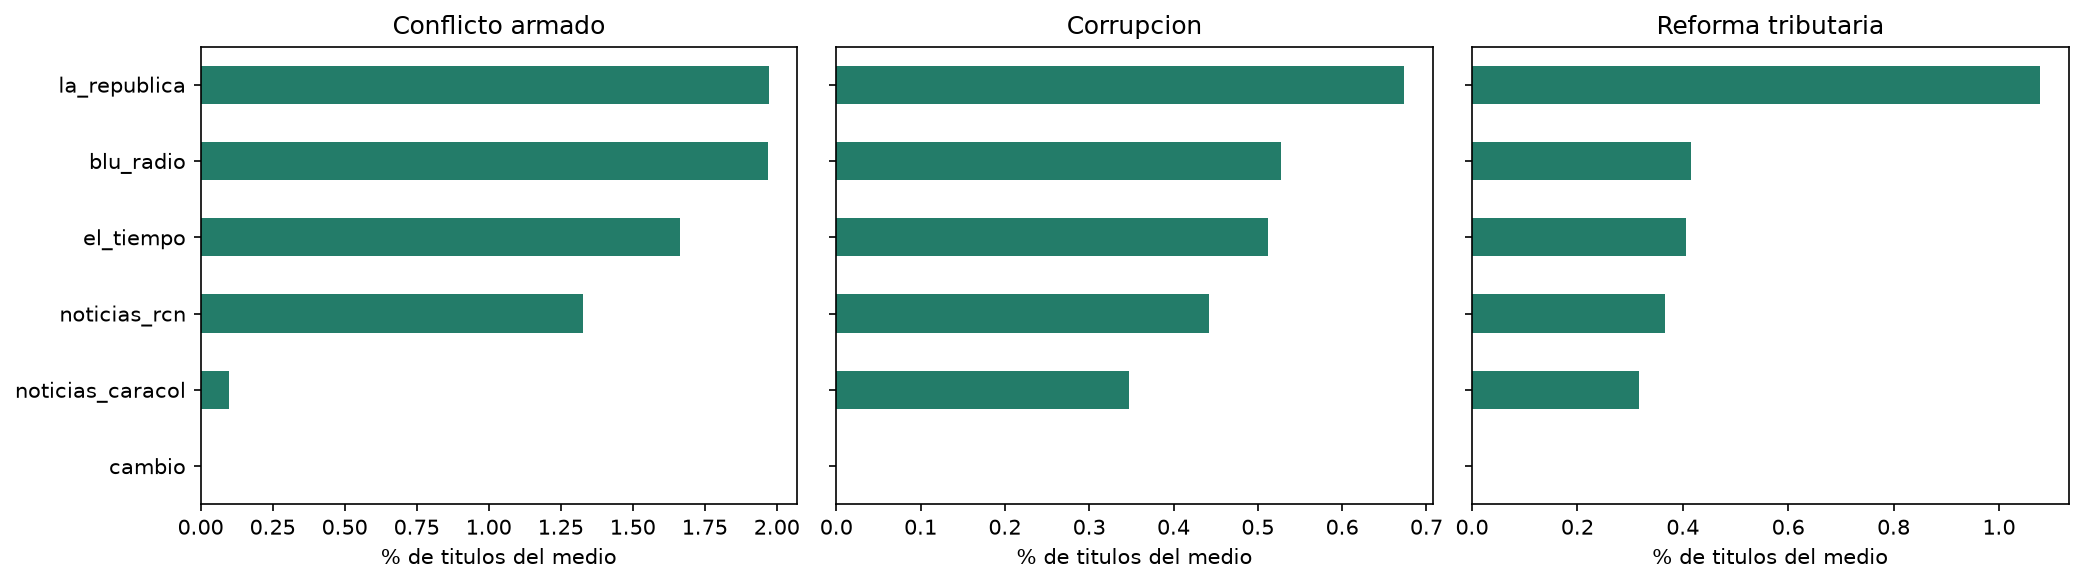

In [10]:
display(Image(filename=str(RESULTS / 'figuras' / 'eventos_framing.png')))

## 4. LDA sobre corpus completo

Se excluyen documentos vacios tras el filtrado del diccionario y se conservan con topico -1 en la asignacion. K se selecciona por c_v en entrenamiento. Perplejidad = 2**(-log_bound); no se confunde con el bound negativo.

In [11]:
display(pd.read_csv(RESULTS / 'lda_optimization.csv'))
display(pd.read_csv(RESULTS / 'lda_topics.csv'))
assignments = pd.read_parquet(RESULTS / 'document_topics.parquet')
assert assignments['article_id'].is_unique
assert len(assignments) == summary['articulos']
display(assignments.head())

,K,coherence_cv,log_perplexity_bound,perplexity_base2
0,3,0.312985,-8.358303,328.170865
1,5,0.359546,-8.609586,390.610330
2,7,0.339047,-8.696535,414.875531
3,10,0.332265,-8.787191,441.782123
4,15,0.309404,-13.083101,8677.726660


,topic,palabra,peso
0,0,emision,0.038050
1,0,bogota,0.028104
2,0,martes,0.010782
3,0,jueves,0.010531
4,0,nacional,0.010107
5,0,miercoles,0.010066
6,0,lunes,0.009937
7,0,colombia,0.009604
8,0,julio,0.008092
9,0,elecciones,0.007578


,article_id,source_id,published_date,year,date_precision,title_source,dominant_topic,topic_confidence
0,229008,blu_radio,2018-08-07,2018,day,slug,2,0.404320
1,229401,blu_radio,2018-08-07,2018,day,slug,2,0.839226
2,229429,blu_radio,2018-08-07,2018,day,slug,2,0.727555
3,229609,blu_radio,2018-08-07,2018,day,slug,2,0.533782
4,229619,blu_radio,2018-08-07,2018,day,slug,2,0.839229


Mejor K en la grilla: 5; c_v=0.3595.

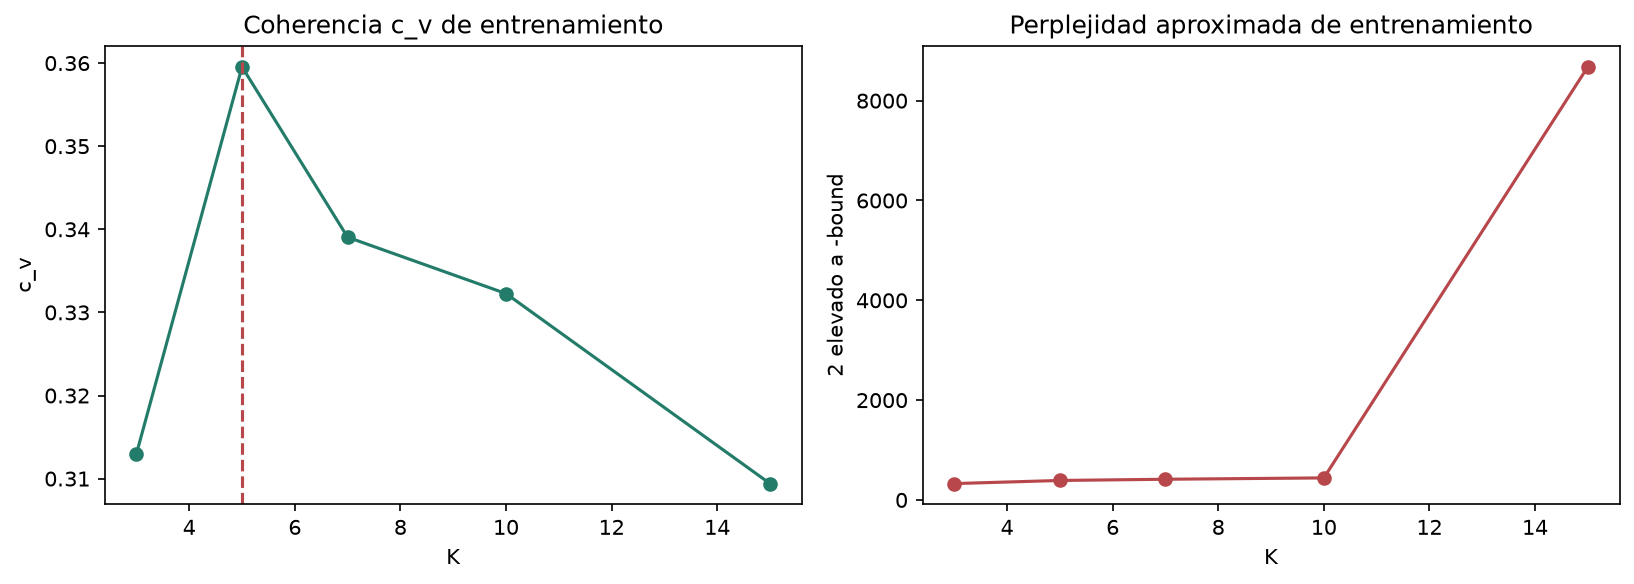

In [12]:
display(Image(filename=str(RESULTS / 'figuras' / 'lda_optimization.png')))

Conteos por medio; el volumen del archivo condiciona la comparacion.

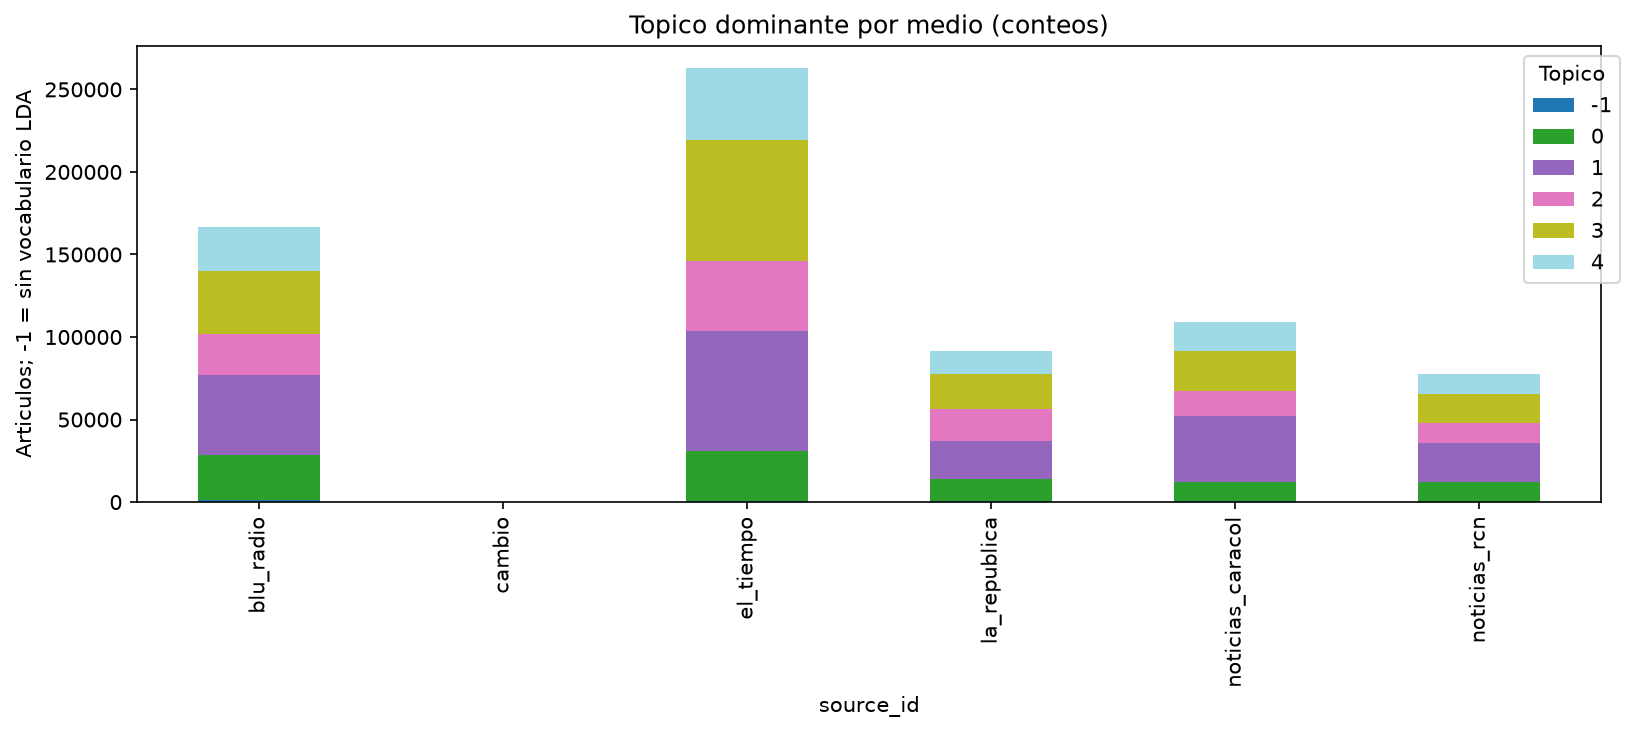

In [13]:
display(Image(filename=str(RESULTS / 'figuras' / 'topics_by_medium.png')))

Proporciones por medio; -1 indica ausencia de vocabulario util.

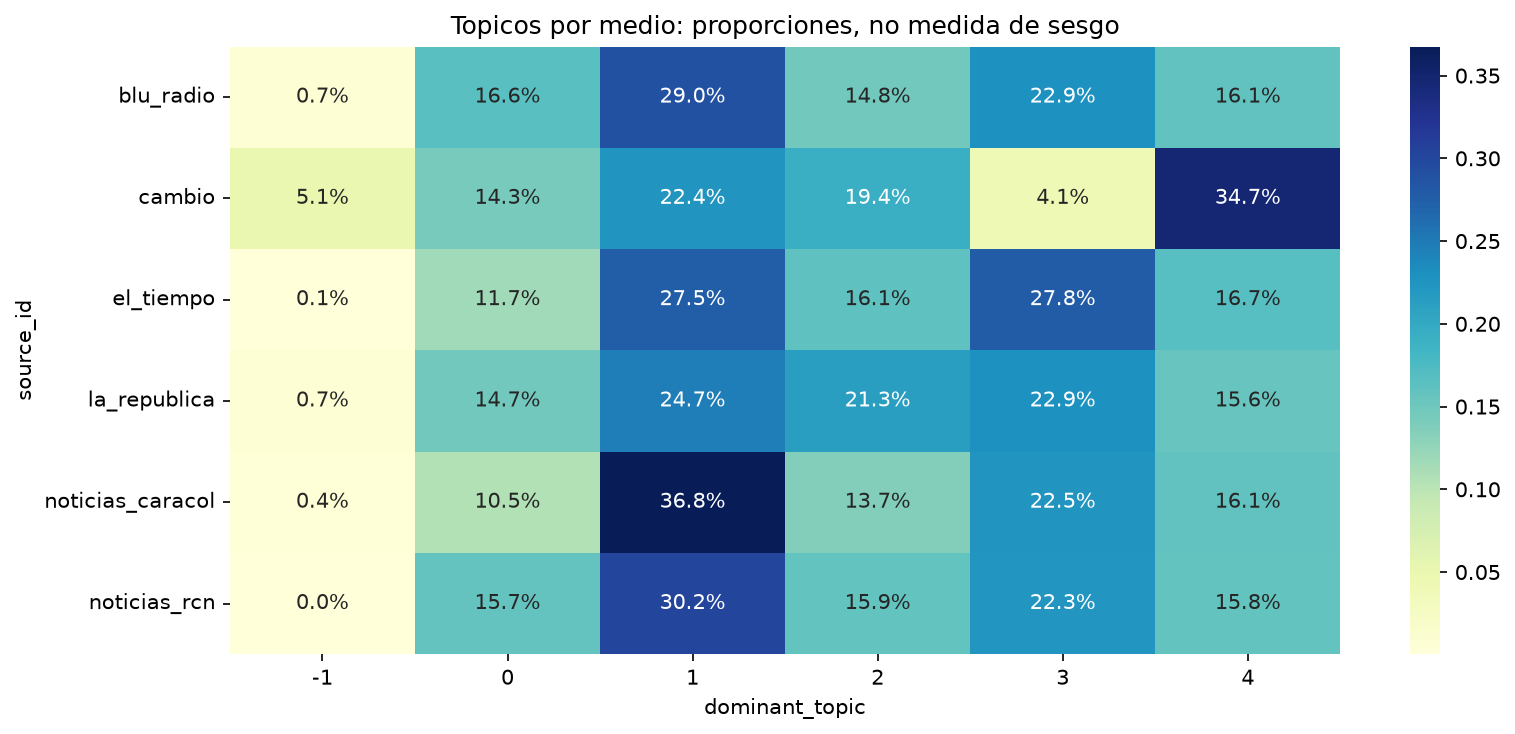

In [14]:
display(Image(filename=str(RESULTS / 'figuras' / 'topics_heatmap.png')))

## 5. Visualizacion interactiva y reproducibilidad

[pyLDAvis](resultados/lda_visualization.html). Los modelos, diccionario, corpus, parametros, versiones y checksum estan en resultados. La visualizacion HTML puede necesitar red para cargar recursos externos de pyLDAvis.

In [15]:
display(summary['versions'])
display(json.loads((RESULTS / 'config.json').read_text()))

{'gensim': '4.4.0',
 'scipy': '1.18.1',
 'numpy': '2.5.3',
 'pandas': '3.0.6',
 'scikit-learn': '1.9.1',
 'pyLDAvis': '3.4.1',
 'nltk': '3.10.3'}

{'input_sha256': 'd3fbac63bcd8de1219745dbcb28d7c39429b30dd7f229728214ab8434997e1f3',
 'topics': [3, 5, 7, 10, 15],
 'passes': 10,
 'no_below': 10,
 'core_sha256': 'ed75afedd83d38d7d6de977bdcf3b2fef63437ad8513385efbf283da1cd73aee'}

## 6. Conclusiones

El export contiene 708,768 registros de 6 medios entre 2018-08-07 y 2022-08-06. Hay 707,553 titulos slug y 1,215 ausentes. Se entrenaron K=[3, 5, 7, 10, 15] sobre 706,083 documentos utiles, con 10 pasadas y semilla 42. K=5 obtuvo el mayor c_v (0.3595) de la grilla.

La Republica tiene 1.08% de coincidencias tributarias respecto a sus titulos; RCN y Blu registran 1.97% y 1.97% en el tema amplio de conflicto. Son proporciones de keywords, no medidas validadas de framing.

El bigrama mas frecuente es 'programa completo' (8,822 apariciones). Programacion de radio y emisiones condicionan los resultados; no confundir formato con posicion editorial.

Estos resultados describen vocabulario y agenda de proxies slug. No permiten afirmar que un medio sea mas sesgado, ni comparar framing del mismo acontecimiento sin verificar los pares y recuperar el texto publicado. La siguiente etapa es validar manualmente los casos y extraer una submuestra balanceada.